**Task 2 : Movie Rating Prediction**

In [346]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score

In [347]:
df = pd.read_csv("Movie.csv",encoding='latin1')

In [348]:
df.head(5)

,Name,Year,Duration,Genre,Rating,Votes,Director,Actor 1,Actor 2,Actor 3
0,,NaN,NaN,Drama,NaN,NaN,J.S. Randhawa,Manmauji,Birbal,Rajendra Bhatia
1,#Gadhvi (He thought he was Gandhi),(2019),109 min,Drama,7.0,8,Gaurav Bakshi,Rasika Dugal,Vivek Ghamande,Arvind Jangid
2,#Homecoming,(2021),90 min,"Drama, Musical",NaN,NaN,Soumyajit Majumdar,Sayani Gupta,Plabita Borthakur,Roy Angana
3,#Yaaram,(2019),110 min,"Comedy, Romance",4.4,35,Ovais Khan,Prateik,Ishita Raj,Siddhant Kapoor
4,...And Once Again,(2010),105 min,Drama,NaN,NaN,Amol Palekar,Rajat Kapoor,Rituparna Sengupta,Antara Mali


In [349]:
df.shape

(15509, 10)

In [350]:
df.isnull().sum()

,0
Name,0
Year,528
Duration,8269
Genre,1877
Rating,7590
Votes,7589
Director,525
Actor 1,1617
Actor 2,2384
Actor 3,3144


In [351]:
df = df[['Duration','Genre','Rating','Votes','Director','Actor 1','Actor 2','Actor 3']]

In [352]:
df=df.dropna()

In [353]:
df['Genre'] = df['Genre'].str.split(',').str[0]
df['Genre'] = pd.factorize(df['Genre'])[0]

In [354]:
df['Votes']= df['Votes'].astype(str).str.replace(',','')
df['Votes'] = pd.to_numeric(df['Votes'],errors='coerce')

In [355]:
df['Rating'] = pd.to_numeric(df['Rating'],errors='coerce')

In [356]:
df['Duration']=df['Duration'].astype(str).str.replace('min','')
df['Duration'] = pd.to_numeric(df['Duration'],errors='coerce')

In [357]:
df.shape

(5659, 8)

In [358]:
df.tail(15)

,Duration,Genre,Rating,Votes,Director,Actor 1,Actor 2,Actor 3
15471,117,1,3.7,6,Karan Kashyap,Mukesh Choudhary,Muntazir Ahmad,Avinash Bhargava
15474,126,0,5.5,51,Kajal Naskar,Manoj Punj,Gurdas Maan,Tabu
15476,155,1,8.2,70344,Zoya Akhtar,Hrithik Roshan,Farhan Akhtar,Abhay Deol
15478,120,12,4.4,33,Ashu Trikha,Mithun Chakraborty,Ranjeeta Kaur,Priyanka Mehta
15479,120,15,6.0,13,Tariq Bhat,Sadhana Singh,Guddi Maruti,Rajesh Puri
15482,140,0,5.7,7,Sumitra Bhave,Sunil Sukthankar,Mita Vashisht,Milind Gunaji
15487,109,3,4.0,351,Satyajit Bhatkal,Darsheel Safary,Anupam Kher,Manjari Fadnnis
15488,100,0,5.7,78,Shlok Sharma,Shashank Arora,Prince Daniel,Shatakshi Gupta
15490,157,3,4.3,268,Sangeeth Sivan,Sunny Deol,Sushmita Sen,Milind Gunaji
15492,150,3,5.6,33,Shibu Mitra,Navin Nischol,Rekha,Urmila Bhatt


In [359]:
df.columns

Index(['Duration', 'Genre', 'Rating', 'Votes', 'Director', 'Actor 1',
       'Actor 2', 'Actor 3'],
      dtype='object')

In [360]:
X = df[['Duration','Genre','Votes','Director','Actor 1','Actor 2','Actor 3']]
y = df['Rating']

In [361]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [362]:
director_score = y_train.groupby(X_train['Director']).mean()
X_train['Director_score'] = X_train['Director'].map(director_score)
X_test['Director_score'] = X_test['Director'].map(director_score)

In [363]:
actor1_score = y_train.groupby(X_train['Actor 1']).mean()
X_train['Actor1_score'] = X_train['Actor 1'].map(actor1_score)
X_test['Actor1_score'] = X_test['Actor 1'].map(actor1_score)

actor2_score = y_train.groupby(X_train['Actor 2']).mean()
X_train['Actor2_score'] = X_train['Actor 2'].map(actor2_score)
X_test['Actor2_score'] = X_test['Actor 2'].map(actor2_score)

actor3_score = y_train.groupby(X_train['Actor 3']).mean()
X_train['Actor3_score'] = X_train['Actor 3'].map(actor3_score)
X_test['Actor3_score'] = X_test['Actor 3'].map(actor3_score)

In [364]:
X_train['Cast_score'] = (
    X_train['Actor1_score'] +
    X_train['Actor2_score'] +
    X_train['Actor3_score']
)/3

X_test['Cast_score'] = (
    X_test['Actor1_score'] +
    X_test['Actor2_score'] +
    X_test['Actor3_score']
)/3

In [365]:
features = [
'Duration',
'Genre',
'Votes',
'Director_score',
'Cast_score'
]
X_train = X_train[features]
X_test = X_test[features]

In [366]:
print(X.shape)

(5659, 7)


In [367]:
model=RandomForestRegressor(
    n_estimators=500,
    max_depth=20,
    min_samples_split=5,
    random_state=42
)

In [368]:
RandomForestRegressor()

RandomForestRegressor()

In [369]:
model.fit(X_train,y_train)

RandomForestRegressor(max_depth=20, min_samples_split=5, n_estimators=500,
                      random_state=42)

In [370]:
y_pred = model.predict(X_test)
print(y_pred[:5])
print(y_test[:5])

[5.46168355 6.05936626 5.44434922 5.85657257 6.30728391]
10971    6.0
14052    2.4
10002    3.8
3970     3.8
8840     7.2
Name: Rating, dtype: float64


In [371]:
print('Mean Absolute Error', mean_absolute_error(y_test,y_pred))
print('Mean Squared Error', mean_squared_error(y_test,y_pred))
print('R2 Score', r2_score(y_test,y_pred))

Mean Absolute Error 0.9520910280542607
Mean Squared Error 1.5362221338164066
R2 Score 0.17039157281516104


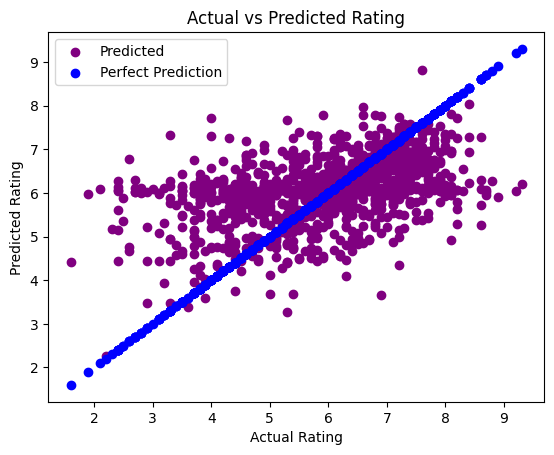

In [372]:
plt.scatter(y_test,y_pred,color='purple',label='Predicted')
plt.scatter(y_test,y_test,color='blue',label='Perfect Prediction')
plt.xlabel('Actual Rating')
plt.ylabel('Predicted Rating')
plt.title('Actual vs Predicted Rating')
plt.legend()
plt.show()

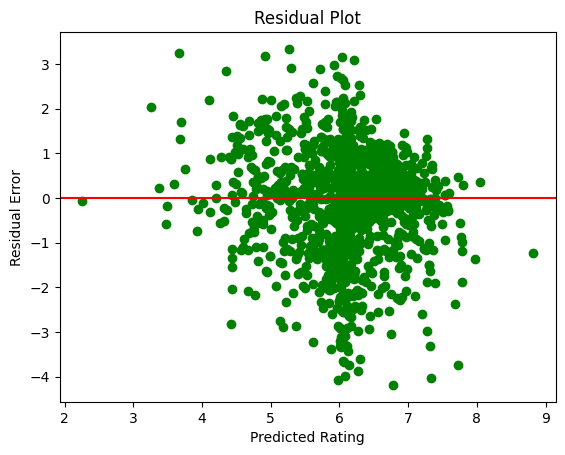

In [373]:
residuals = y_test - y_pred

plt.scatter(y_pred,residuals,color='green')
plt.axhline(y=0, color ='red')
plt.xlabel('Predicted Rating')
plt.ylabel('Residual Error')
plt.title('Residual Plot')
plt.show()

In [374]:
y.value_counts()

,count
Rating,
6.8,200
6.5,192
6.2,190
6.6,163
7.1,163
...,...
9.2,2
9.7,1
1.4,1


In [375]:
tolerance = 1
accuracy = np.mean(np.abs(y_test - y_pred) <= tolerance)
print('Tolerance Accuracy: ',accuracy)

Tolerance Accuracy:  0.6051236749116607


In [376]:
new_movie = pd.DataFrame({
        'Duration': [142],
        'Genre': [2] ,
        'Votes': [1000],
        'Director_score': [7],
        'Cast_score' :[7]
})

prediction = model.predict(new_movie)
print('Predicted Rating:',prediction)

Predicted Rating: [7.4985139]
